# Redes Convolucionales

In [1]:
from typing import Callable
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import supervision as sv
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import datasets, transforms
from torchinfo import summary
import torch.nn.functional as F

Preparamos los datasets

In [2]:
BATCH_SIZE = 8

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # image = (image - mean) / std
])

train_dataset    = datasets.MNIST(root='.', download=True, train=True, transform=img_transform)
n_samples = 1000
train_subset = Subset(train_dataset, range(n_samples))

train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset    = datasets.MNIST(root='.', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Definimos la arquitectura: Red Convolucional

In [3]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        
        # TODO: Conv-net (3 capas convolucionales + 2 FC)
        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=16,
                               kernel_size=3)
        # https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html 
        # padding can also be a string 'same' or 'valid'
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        #self.conv3 = nn.Conv2d(32, 64, kernel_size=3)

        self.fc1 = nn.Linear(32*22*22, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=1)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=1)

        x = torch.flatten(x, 1)
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)

        return x

In [4]:
# Podemos usar GPU si está disponible (si tenes gpu de nvidia pone use_gpu = True)
use_gpu = False
device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")

convnet = ConvNet()
convnet = convnet.to(device)

summary(convnet, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
ConvNet                                  [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 26, 26]           160
├─Conv2d: 1-2                            [1, 32, 23, 23]           4,640
├─Linear: 1-3                            [1, 128]                  1,982,592
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 1,988,682
Trainable params: 1,988,682
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.55
Input size (MB): 0.00
Forward/backward pass size (MB): 0.22
Params size (MB): 7.95
Estimated Total Size (MB): 8.18

Training ...


100%|██████████| 125/125 [00:01<00:00, 100.25it/s]


Epoch [1 / 50] average loss: 0.867598


100%|██████████| 125/125 [00:01<00:00, 105.01it/s]


Epoch [2 / 50] average loss: 0.190847


...

Epoch [48 / 50] average loss: 0.000001


100%|██████████| 125/125 [00:01<00:00, 105.32it/s]


Epoch [49 / 50] average loss: 0.000001


100%|██████████| 125/125 [00:01<00:00, 106.16it/s]


Epoch [50 / 50] average loss: 0.000001


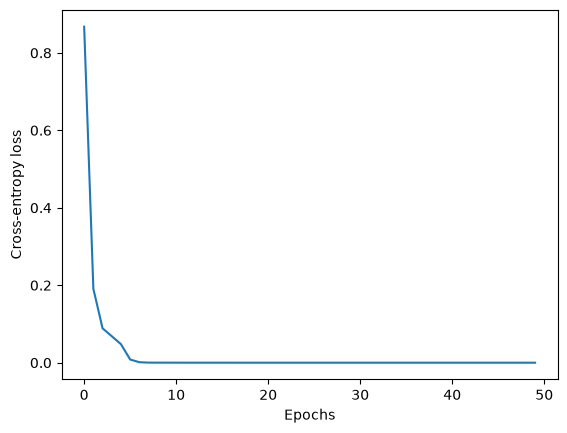

In [5]:
num_epochs = 50
learning_rate = 2e-3

# Optimizador
optimizer = torch.optim.Adam(params=convnet.parameters(), lr=learning_rate)

# red en modo training
convnet.train()

train_loss_avg = []

# loss function (Cross Entropy)
criterion = nn.CrossEntropyLoss()

print('Training ...')
for epoch in range(num_epochs):
    train_loss_avg.append(0)
    num_batches = 0
    
    for image_batch, label_batch in tqdm(train_dataloader):
        
        # TODO: Batch y etiquetas a memoria del dispositivo
        image_batch = image_batch.to(device)
        label_batch = label_batch.to(device)
        # TODO: Computar predicciones 
        preds = convnet(image_batch)
        # discard the extra dimension
        preds = preds.squeeze(dim=1)
        # TODO: Loss
        loss = criterion(preds, label_batch)
        # TODO: backpropagation
        optimizer.zero_grad()
        loss.backward()
        # TODO: paso del optimizador (usando los gradientes computados por backpropagation)
        optimizer.step()

        train_loss_avg[-1] += loss.item()
        num_batches += 1
        
    train_loss_avg[-1] /= num_batches
    print('Epoch [%d / %d] average loss: %f' % (epoch+1, num_epochs, train_loss_avg[-1]))

# Graficar la evolución de la loss function para el entrenamiento
plt.figure()
plt.plot(train_loss_avg)
plt.xlabel('Epochs')
plt.ylabel('Cross-entropy loss')
plt.show()

In [7]:
# Evaluation loop
correct = 0
total = 0
convnet.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = convnet(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9505
